In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [2]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e5/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e5/test.csv")
sample_submission = pd.read_csv("/kaggle/input/competitions/playground-series-s6e5/sample_submission.csv")

In [3]:
print("Train Shape :", train.shape)
print("Test Shape :", test.shape)

Train Shape : (439140, 16)
Test Shape : (188165, 15)


In [4]:
train.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change     

In [6]:
train.describe()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


In [7]:
missing_values = train.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [8]:
print("Duplicate Rows :", train.duplicated().sum())

Duplicate Rows : 0


In [9]:
target = "PitNextLap"

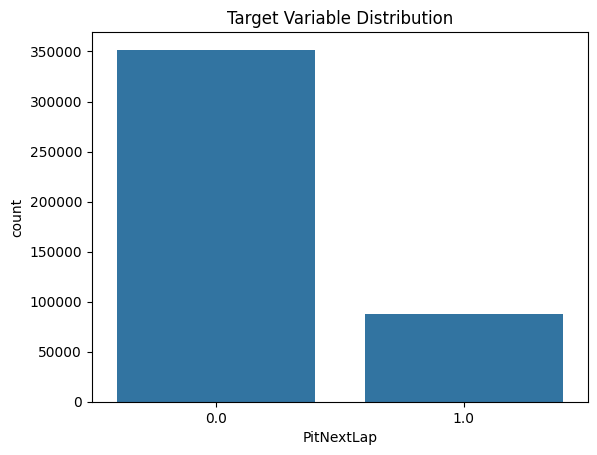

In [10]:
sns.countplot(x=train[target])

plt.title("Target Variable Distribution")

plt.show()

In [11]:
train[target].value_counts(normalize=True)

PitNextLap
0.0    0.801018
1.0    0.198982
Name: proportion, dtype: float64

In [12]:
cat_cols = train.select_dtypes(include=["object"]).columns.tolist()

num_cols = train.select_dtypes(include=["int64", "float64"]).columns.tolist()

if target in num_cols:
    num_cols.remove(target)

print("Categorical Columns :", len(cat_cols))
print("Numerical Columns :", len(num_cols))

Categorical Columns : 3
Numerical Columns : 12


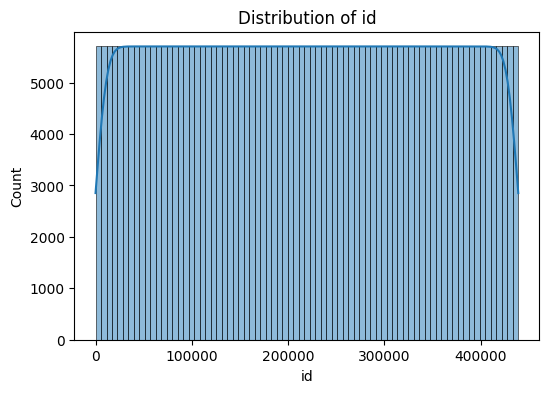

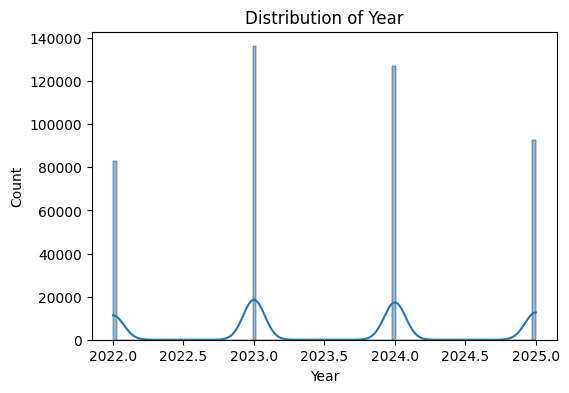

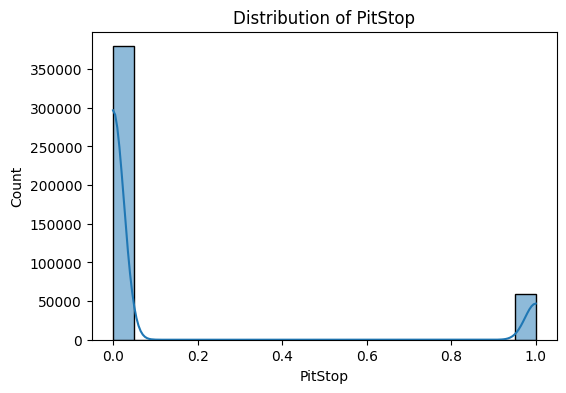

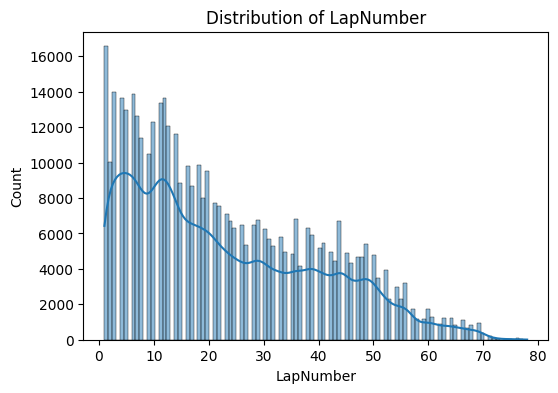

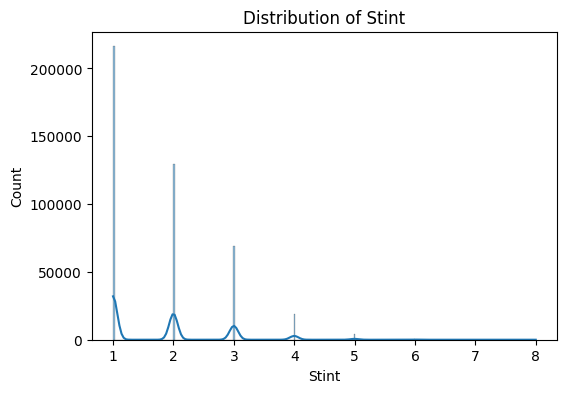

In [13]:
for col in num_cols[:5]:
    
    plt.figure(figsize=(6,4))
    
    sns.histplot(train[col], kde=True)
    
    plt.title(f"Distribution of {col}")
    
    plt.show()

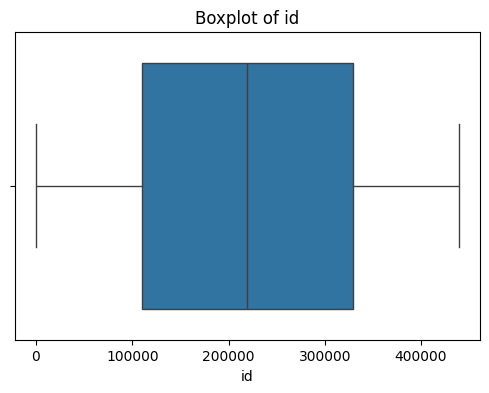

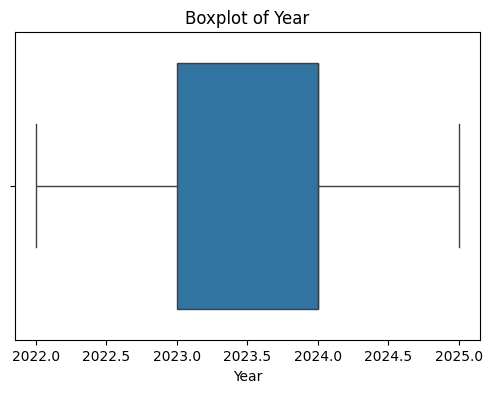

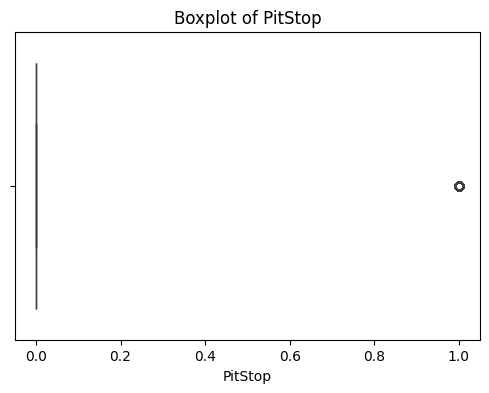

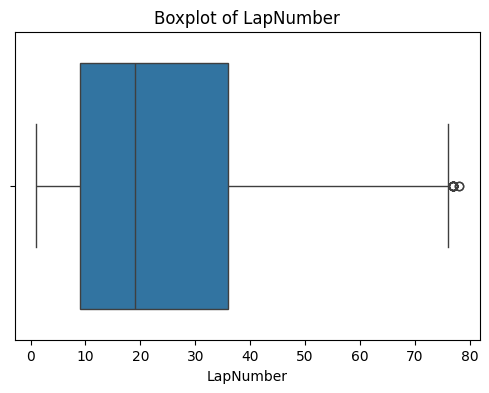

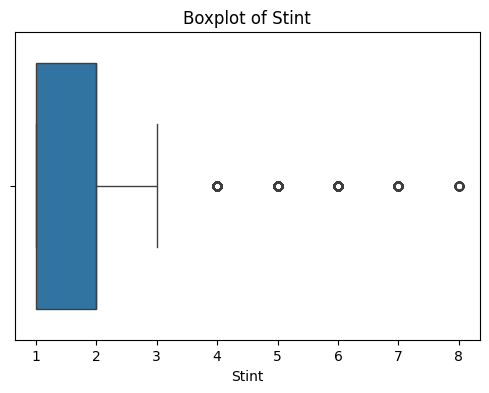

In [14]:
for col in num_cols[:5]:
    
    plt.figure(figsize=(6,4))
    
    sns.boxplot(x=train[col])
    
    plt.title(f"Boxplot of {col}")
    
    plt.show()

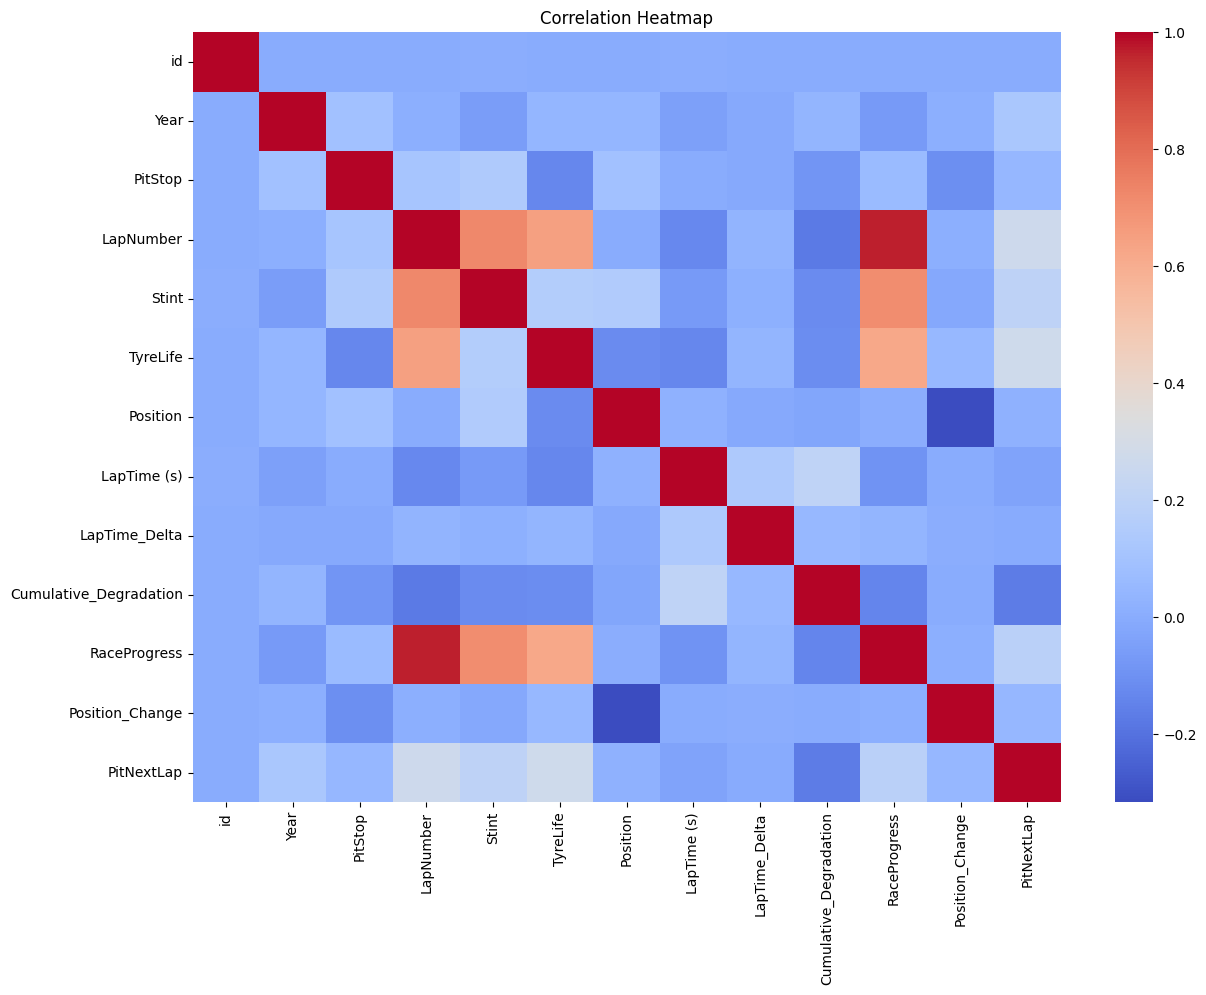

In [15]:
plt.figure(figsize=(14,10))

corr_matrix = train[num_cols + [target]].corr()

sns.heatmap(corr_matrix, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [16]:
num_imputer = SimpleImputer(strategy="median")

train[num_cols] = num_imputer.fit_transform(train[num_cols])

test[num_cols] = num_imputer.transform(test[num_cols])

In [17]:
for col in cat_cols:
    
    train[col] = train[col].fillna(train[col].mode()[0])
    
    test[col] = test[col].fillna(test[col].mode()[0])

In [18]:
label_encoders = {}

for col in cat_cols:
    
    le = LabelEncoder()
    
    train[col] = le.fit_transform(train[col])
    
    test[col] = le.transform(test[col])
    
    label_encoders[col] = le

In [19]:
for col in num_cols[:5]:
    
    train[f"{col}_squared"] = train[col] ** 2
    
    test[f"{col}_squared"] = test[col] ** 2

In [20]:
for col in num_cols[:5]:
    
    train[f"{col}_log"] = np.log1p(train[col])
    
    test[f"{col}_log"] = np.log1p(test[col])

In [21]:
X = train.drop(columns=[target])

y = train[target]

X_test = test.copy()

In [22]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [23]:
lr_auc_scores = []

for train_idx, valid_idx in skf.split(X, y):
    
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
    
    model = LogisticRegression(max_iter=1000)
    
    model.fit(X_train, y_train)
    
    preds = model.predict_proba(X_valid)[:,1]
    
    auc = roc_auc_score(y_valid, preds)
    
    lr_auc_scores.append(auc)

print("Logistic Regression ROC AUC :", np.mean(lr_auc_scores))

Logistic Regression ROC AUC : 0.44165538272389027


In [24]:
rf_auc_scores = []

for train_idx, valid_idx in skf.split(X, y):
    
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
    
    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    
    preds = model.predict_proba(X_valid)[:,1]
    
    auc = roc_auc_score(y_valid, preds)
    
    rf_auc_scores.append(auc)

print("Random Forest ROC AUC :", np.mean(rf_auc_scores))

Random Forest ROC AUC : 0.930361669680347


In [25]:
xgb_auc_scores = []

for train_idx, valid_idx in skf.split(X, y):
    
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
    
    model = XGBClassifier(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="auc",
        random_state=42
    )
    
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        verbose=100
    )
    
    preds = model.predict_proba(X_valid)[:,1]
    
    auc = roc_auc_score(y_valid, preds)
    
    xgb_auc_scores.append(auc)

print("XGBoost ROC AUC :", np.mean(xgb_auc_scores))

[0]	validation_0-auc:0.91249
[100]	validation_0-auc:0.93440
[200]	validation_0-auc:0.93953
[300]	validation_0-auc:0.94229
[400]	validation_0-auc:0.94399
[500]	validation_0-auc:0.94513
[600]	validation_0-auc:0.94603
[700]	validation_0-auc:0.94663
[800]	validation_0-auc:0.94706
[900]	validation_0-auc:0.94746
[999]	validation_0-auc:0.94781
[0]	validation_0-auc:0.91102
[100]	validation_0-auc:0.93310
[200]	validation_0-auc:0.93787
[300]	validation_0-auc:0.94073
[400]	validation_0-auc:0.94245
[500]	validation_0-auc:0.94353
[600]	validation_0-auc:0.94437
[700]	validation_0-auc:0.94506
[800]	validation_0-auc:0.94559
[900]	validation_0-auc:0.94602
[999]	validation_0-auc:0.94622
[0]	validation_0-auc:0.91310
[100]	validation_0-auc:0.93441
[200]	validation_0-auc:0.93924
[300]	validation_0-auc:0.94181
[400]	validation_0-auc:0.94339
[500]	validation_0-auc:0.94456
[600]	validation_0-auc:0.94539
[700]	validation_0-auc:0.94593
[800]	validation_0-auc:0.94639
[900]	validation_0-auc:0.94675
[999]	validati

In [26]:
lgb_auc_scores = []

for train_idx, valid_idx in skf.split(X, y):
    
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
    
    model = LGBMClassifier(
        n_estimators=2000,
        learning_rate=0.02,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)]
    )
    
    preds = model.predict_proba(X_valid)[:,1]
    
    auc = roc_auc_score(y_valid, preds)
    
    lgb_auc_scores.append(auc)

print("LightGBM ROC AUC :", np.mean(lgb_auc_scores))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 69904, number of negative: 281408
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016461 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2474
[LightGBM] [Info] Number of data points in the train set: 351312, number of used features: 25
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.198980 -> initscore=-1.392683
[LightGBM] [Info] Start training from score -1.392683
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

In [27]:
cat_auc_scores = []

for train_idx, valid_idx in skf.split(X, y):
    
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
    
    model = CatBoostClassifier(
        iterations=3000,
        learning_rate=0.02,
        depth=6,
        eval_metric="AUC",
        random_seed=42,
        verbose=200
    )
    
    model.fit(
        X_train,
        y_train,
        eval_set=(X_valid, y_valid)
    )
    
    preds = model.predict_proba(X_valid)[:,1]
    
    auc = roc_auc_score(y_valid, preds)
    
    cat_auc_scores.append(auc)

print("CatBoost ROC AUC :", np.mean(cat_auc_scores))

0:	test: 0.8962940	best: 0.8962940 (0)	total: 115ms	remaining: 5m 44s
200:	test: 0.9249431	best: 0.9249431 (200)	total: 10.4s	remaining: 2m 25s
400:	test: 0.9324787	best: 0.9324787 (400)	total: 20.5s	remaining: 2m 12s
600:	test: 0.9363952	best: 0.9363952 (600)	total: 30.6s	remaining: 2m 1s
800:	test: 0.9389637	best: 0.9389637 (800)	total: 40.8s	remaining: 1m 51s
1000:	test: 0.9406232	best: 0.9406232 (1000)	total: 50.9s	remaining: 1m 41s
1200:	test: 0.9418069	best: 0.9418069 (1200)	total: 1m	remaining: 1m 31s
1400:	test: 0.9427138	best: 0.9427138 (1400)	total: 1m 9s	remaining: 1m 18s
1600:	test: 0.9434669	best: 0.9434669 (1600)	total: 1m 17s	remaining: 1m 7s
1800:	test: 0.9440973	best: 0.9440973 (1800)	total: 1m 25s	remaining: 57s
2000:	test: 0.9445968	best: 0.9445968 (2000)	total: 1m 33s	remaining: 46.9s
2200:	test: 0.9450352	best: 0.9450352 (2200)	total: 1m 42s	remaining: 37.1s
2400:	test: 0.9453907	best: 0.9453907 (2400)	total: 1m 50s	remaining: 27.6s
2600:	test: 0.9457007	best: 0.94

In [28]:
scores = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],
    "ROC_AUC": [
        np.mean(lr_auc_scores),
        np.mean(rf_auc_scores),
        np.mean(xgb_auc_scores),
        np.mean(lgb_auc_scores),
        np.mean(cat_auc_scores)
    ]
})

scores.sort_values(by="ROC_AUC", ascending=False)

,Model,ROC_AUC
2,XGBoost,0.946875
3,LightGBM,0.946130
4,CatBoost,0.945411
1,Random Forest,0.930362
0,Logistic Regression,0.441655


In [29]:
final_model = CatBoostClassifier(
    iterations=3000,
    learning_rate=0.02,
    depth=6,
    eval_metric="AUC",
    random_seed=42,
    verbose=200
)

final_model.fit(X, y)

0:	total: 49ms	remaining: 2m 27s
200:	total: 9s	remaining: 2m 5s
400:	total: 17.7s	remaining: 1m 54s
600:	total: 26.7s	remaining: 1m 46s
800:	total: 35.5s	remaining: 1m 37s
1000:	total: 44.2s	remaining: 1m 28s
1200:	total: 52.9s	remaining: 1m 19s
1400:	total: 1m 1s	remaining: 1m 10s
1600:	total: 1m 10s	remaining: 1m 1s
1800:	total: 1m 18s	remaining: 52.4s
2000:	total: 1m 27s	remaining: 43.5s
2200:	total: 1m 35s	remaining: 34.8s
2400:	total: 1m 44s	remaining: 26.1s
2600:	total: 1m 53s	remaining: 17.4s
2800:	total: 2m 1s	remaining: 8.64s
2999:	total: 2m 10s	remaining: 0us


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=3000, learning_rate=0.02, random_seed=42, verbose=200)

In [30]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": final_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
4,Year,18.690072
21,Year_log,16.669220
16,Year_squared,13.610618
8,TyreLife,8.493817
24,Stint_log,5.897310
19,Stint_squared,5.082795
3,Race,4.870444
11,LapTime_Delta,4.802963
7,Stint,4.683852
2,Compound,3.492206


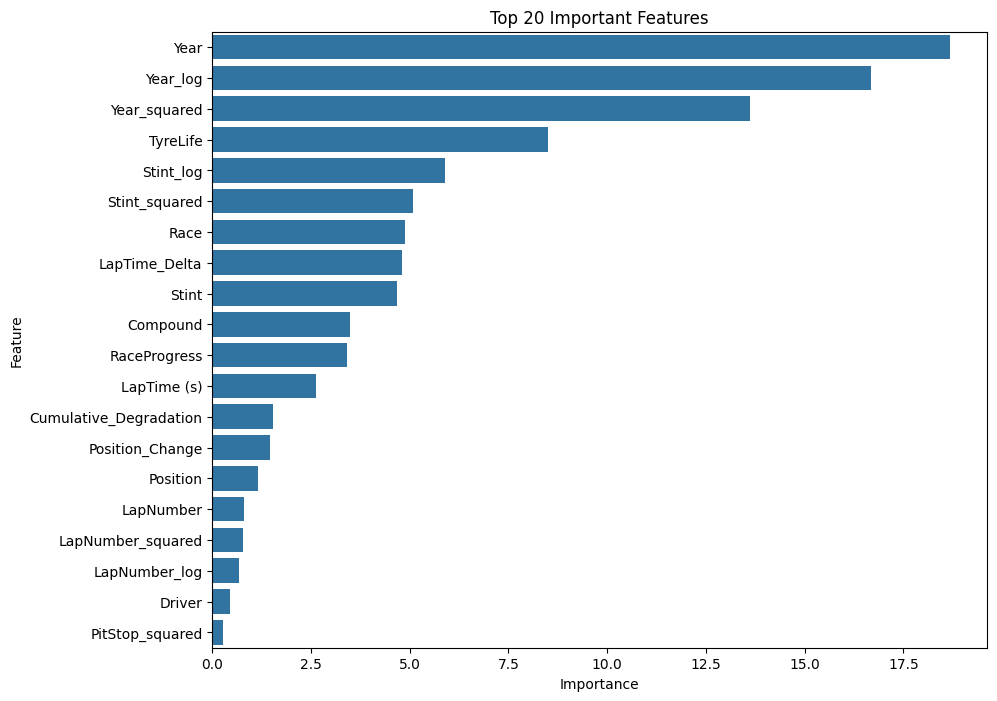

In [31]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Important Features")

plt.show()

In [32]:
test_predictions = final_model.predict_proba(X_test)[:,1]

In [33]:
sample_submission[target] = test_predictions

sample_submission.head()

,id,PitNextLap
0,439140,0.004068
1,439141,0.001949
2,439142,0.004754
3,439143,0.086098
4,439144,0.773992


In [34]:
sample_submission.to_csv("submission.csv", index=False)

print("Submission File Saved Successfully")

Submission File Saved Successfully
